<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="在 Colab 中打开"/></a>

[查看源码](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb) | [查看幻灯片](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/slides/01_pytorch_workflow.pdf) | [观看视频讲解](https://youtu.be/Z_ikDlimN6A?t=15419) 

# 01. PyTorch 工作流基础

机器学习和深度学习的本质是：拿到过去的数据，构建一个算法（如神经网络）去发现其中模式，再利用这些模式预测未来。

实现这一点有很多方法，而且新方法也在不断出现。

但我们先从小问题开始。

先从一条直线怎么样？

看看我们能否构建一个 PyTorch 模型，学到这条直线背后的模式并拟合它。

## 本章会讲什么

本模块会覆盖一个标准的 PyTorch 工作流（你可以按实际需求调整，但它包含了核心步骤框架）。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" width=900 alt="PyTorch 工作流示意图"/>

目前我们会用这个流程去预测一条简单直线，不过同一套步骤可以根据具体问题重复使用和调整。

具体包括：

| **主题** | **内容** |
| ----- | ----- |
| **1. 准备数据** | 数据可以是任何形式，但为了起步我们先创建一条简单直线 |
| **2. 构建模型** | 创建一个学习数据模式的模型，同时选择 **损失函数**、**优化器** 并构建 **训练循环**。 | 
| **3. 拟合数据（训练）** | 现在有了数据和模型，让模型在（**训练集**）上尝试学习模式。 |
| **4. 预测与评估（推理）** | 模型学到模式后，把它在（**测试集**）上的结果与真实值进行比较。 |
| **5. 保存与加载模型** | 你可能想在别处复用模型，或之后再继续使用，这里会讲。 |
| **6. 整体串起来** | 将以上所有步骤整合到一起。 |


## 去哪里求助？

本课程所有材料都[托管在 GitHub](https://github.com/mrdbourke/pytorch-deep-learning)。

如果你遇到问题，也可以在那里的 [Discussions 页面](https://github.com/mrdbourke/pytorch-deep-learning/discussions)提问。

此外还有 [PyTorch 开发者论坛](https://discuss.pytorch.org/)，这是一个非常有帮助的 PyTorch 交流社区。

我们先把本章内容写进一个字典，后面便于参考。


In [ ]:
what_were_covering = {1: "数据（准备与加载）",
    2: "构建模型",
    3: "将模型拟合到数据（训练）",
    4: "进行预测并评估模型（推理）",
    5: "保存与加载模型",
    6: "把它们全部串起来"
}

接下来导入本模块需要的库。

我们会用到 `torch`、`torch.nn`（`nn` 代表 neural network，这个包包含了在 PyTorch 中构建神经网络的基础模块）以及 `matplotlib`。

In [ ]:
import torch
from torch import nn # nn 包含 PyTorch 中神经网络的基础模块
import matplotlib.pyplot as plt

# 检查 PyTorch 版本
torch.__version__

'1.12.1+cu113'

## 1. 数据（准备与加载）

我想强调，机器学习里的“数据”几乎可以是任何你能想到的形式：数字表格（像大型 Excel）、各种图像、视频（YouTube 上就有大量数据）、音频（歌曲或播客）、蛋白质结构、文本等等。

![machine learning is a game of two parts: 1. turn your data into a representative set of numbers and 2. build or pick a model to learn the representation as best as possible](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-machine-learning-a-game-of-two-parts.png)

机器学习通常是两部分的组合：
1. 把你的数据（无论是什么）转换为数字表示（representation）。
2. 选择或构建一个模型，让它尽可能学好这种表示。

有时这两步也会同时进行。

但如果你手头没有数据怎么办？

这正是我们现在的情况。

没有现成数据。

但我们可以自己创建。

先构造一条直线作为数据。

我们会用[线性回归](https://en.wikipedia.org/wiki/Linear_regression)创建具有已知 **参数**（可被模型学习的量）的数据，再用 PyTorch 看看能否通过 [**梯度下降**](https://en.wikipedia.org/wiki/Gradient_descent) 构建模型来估计这些参数。

如果你现在对这些术语还不熟悉也没关系，后面会在代码中看到它们的实际作用，我也会在下方提供更多学习资源。



In [ ]:
# 创建已知参数
weight = 0.7
bias = 0.3

# 创建数据
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

太好了！接下来我们要构建一个模型，让它学习 `X`（**特征**）与 `y`（**标签**）之间的关系。

### 将数据划分为训练集和测试集

我们现在有数据了。

但在建模之前，需要先划分数据集。

在机器学习项目中，最关键步骤之一就是创建训练集和测试集（必要时还包括验证集）。

每个数据切分各有用途：

| 划分 | 作用 | 占总数据比例 | 使用频率 |
| ----- | ----- | ----- | ----- |
| **训练集** | 模型从这部分数据中学习（类似你学期中学习的课程内容）。 | ~60-80% | 总是使用 |
| **验证集** | 用于调参（类似期末前做的模拟考试）。 | ~10-20% | 常用但不一定每次都用 |
| **测试集** | 用于评估模型学到了什么（类似学期末的正式考试）。 | ~10-20% | 总是使用 |

目前我们只用训练集和测试集，也就是既有模型学习的数据，也有独立评估的数据。

我们通过切分 `X` 和 `y` 张量来创建它们。

> **注意：** 在真实项目中，这一步通常在最开始就完成（测试集应始终与其他数据隔离）。我们希望模型先在训练集上学习，再在测试集上评估，以判断它对未见样本的 **泛化能力**。


In [ ]:
# 创建训练集/测试集切分
train_split = int(0.8 * len(X)) # 80% 训练，20% 测试
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

很好，我们有 40 个训练样本（`X_train` 与 `y_train`）和 10 个测试样本（`X_test` 与 `y_test`）。

接下来创建的模型会尝试学习 `X_train` 与 `y_train` 的关系，然后我们再用 `X_test` 和 `y_test` 评估它学到的内容。

不过现在的数据还只是页面上的数字。

我们先写一个可视化函数。

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  绘制训练数据、测试数据，并对比预测结果。
  """
  plt.figure(figsize=(10, 7))

  # 用蓝色绘制训练数据
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # 用绿色绘制测试数据
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # 用红色绘制预测结果（预测基于测试数据）
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # 显示图例
  plt.legend(prop={"size": 14});

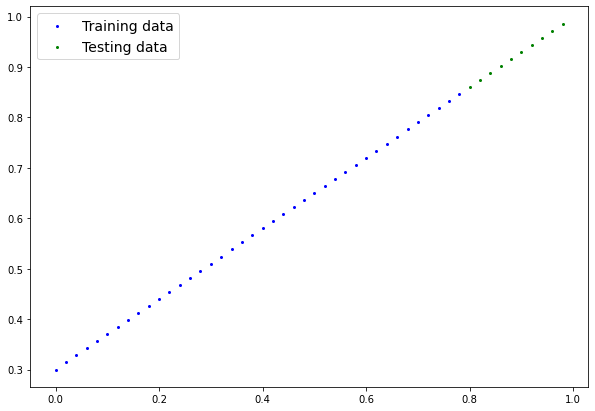

In [6]:
plot_predictions();

很棒！

现在它不再只是页面上的数字，而是一条可视化的直线。

> **注意：** 这里很适合引入数据探索者的口号："visualize, visualize, visualize!"
 >
 > 每当你在处理数据并把它转换成数字时，都记住这句话。只要你能把东西可视化，理解就会轻松很多。
 >
 > 机器喜欢数字，我们人类也喜欢数字，但我们同样很依赖视觉。

## 2. 构建模型

现在有了数据，我们来构建一个模型，用蓝点去预测绿点。

我们直接上手。

先写代码，再解释细节。

先用纯 PyTorch 复现一个标准线性回归模型。

In [ ]:
# 创建线性回归模型类
class LinearRegressionModel(nn.Module): # <- 在 PyTorch 中几乎一切都基于 nn.Module（可把它看作神经网络乐高积木）
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- 以随机权重开始（模型学习过程中会更新）
                                                dtype=torch.float), # <- PyTorch 默认偏好 float32
                                   requires_grad=True) # <- 这个值是否可通过梯度下降更新？

        self.bias = nn.Parameter(torch.randn(1, # <- 以随机偏置开始（模型学习过程中会更新）
                                            dtype=torch.float), # <- PyTorch 默认偏好 float32
                                requires_grad=True) # <- 这个值是否可通过梯度下降更新？

    # forward 定义模型中的计算过程
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- x 是输入数据（如训练/测试特征）
        return self.weights * x + self.bias # <- 线性回归公式（y = m*x + b）

上面的内容看起来信息不少，我们一步步拆开。

> **资源：** 我们会用 Python 类来构建神经网络组件。如果你不熟悉 Python 的类语法，建议多读几遍 [Real Python 的 Python 3 面向对象编程指南](https://realpython.com/python3-object-oriented-programming/)。


### 构建 PyTorch 模型的核心要素

PyTorch 有四个（大致）核心模块，可以帮助你构建几乎任何类型的神经网络。

它们是 [`torch.nn`](https://pytorch.org/docs/stable/nn.html)、[`torch.optim`](https://pytorch.org/docs/stable/optim.html)、[`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) 和 [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html)。目前我们先聚焦前两个，后两个稍后再讲（你也许已经能猜到它们是做什么的）。

| PyTorch 模块 | 作用 |
| ----- | ----- |
| [`torch.nn`](https://pytorch.org/docs/stable/nn.html) | 包含计算图（按特定方式执行的一系列计算）的基础构件。 |
| [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html#parameter) | 存储可与 `nn.Module` 配合使用的张量。若 `requires_grad=True`，会自动计算梯度（用于通过[**梯度下降**](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html)更新参数），常称为 "autograd"。  | 
| [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | 所有神经网络模块的基类，神经网络积木几乎都继承它。在 PyTorch 中构建模型时，通常应继承 `nn.Module`，并实现 `forward()` 方法。 | 
| [`torch.optim`](https://pytorch.org/docs/stable/optim.html) | 包含各种优化算法（指导 `nn.Parameter` 中参数如何更新，以改进梯度下降并降低损失）。 | 
| `def forward()` | 所有 `nn.Module` 子类都需要 `forward()` 方法，它定义了传入该模块数据时要执行的计算（例如上面的线性回归公式）。 |

如果上面看起来有点复杂，可以这样理解：PyTorch 神经网络里几乎一切都来自 `torch.nn`，
* `nn.Module` 提供更大的积木（层）
* `nn.Parameter` 提供更小的参数（如权重和偏置，它们组合起来构成 `nn.Module`）
* `forward()` 告诉这些大积木如何对输入（装着数据的张量）执行计算
* `torch.optim` 提供优化方法，告诉 `nn.Parameter` 里的参数如何变得更好以表示输入数据

![a pytorch linear model with annotations](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png)
*通过继承 `nn.Module` 构建 PyTorch 模型的基础组件。凡是继承 `nn.Module` 的对象，都必须定义 `forward()` 方法。*

> **资源：** 更多核心模块及其用法可参考 [PyTorch Cheat Sheet](https://pytorch.org/tutorials/beginner/ptcheat.html)。



### 检查 PyTorch 模型内容
现在基础概念到位了，我们先用刚才定义的类创建模型实例，再通过 [`.parameters()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters) 检查其参数。

In [ ]:
# 由于 nn.Parameter 会随机初始化，这里设置随机种子
torch.manual_seed(42)

# 创建模型实例（这是一个包含 nn.Parameter 的 nn.Module 子类）
model_0 = LinearRegressionModel()

# 检查我们创建的 nn.Module 子类中的 nn.Parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

我们也可以用 [`.state_dict()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.state_dict) 获取模型状态（即模型中包含的内容）。

In [ ]:
# 列出具名参数
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

你会注意到 `model_0.state_dict()` 里的 `weights` 和 `bias` 是随机浮点张量。

这是因为我们上面用 `torch.randn()` 初始化了它们。

本质上，我们希望从随机参数起步，让模型逐步把它们更新为更匹配数据的参数（也就是我们构造直线数据时写死的 `weight` 和 `bias`）。

> **练习：** 试着修改上面两个单元中的 `torch.manual_seed()` 数值，看看权重和偏置如何变化。

由于模型现在从随机值开始，它当前的预测能力还比较弱。



### 使用 `torch.inference_mode()` 进行预测
我们可以把测试数据 `X_test` 传给模型，检查它对 `y_test` 的拟合程度。

当数据传入模型时，会经过模型的 `forward()` 方法，并按我们定义的计算流程输出结果。

现在来做预测。

In [ ]:
# 使用模型进行预测
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# 注意：在旧版 PyTorch 代码中你也会看到 torch.no_grad()
# with torch.no_grad()：
#   示例旧写法：model_0(X_test)


嗯？

你可能注意到我们用了 [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) 这个[上下文管理器](https://realpython.com/python-with-statement/)（也就是 `with torch.inference_mode():`）来做预测。

顾名思义，`torch.inference_mode()` 适用于模型推理阶段（即做预测时）。

`torch.inference_mode()` 会关闭一系列训练阶段才需要的功能（例如梯度跟踪），从而让 **forward pass**（数据经过 `forward()` 方法）更快。

> **注意：** 在旧版 PyTorch 代码中，你也会看到 `torch.no_grad()` 用于推理。`torch.inference_mode()` 与 `torch.no_grad()` 作用相近，
`torch.inference_mode()` 更新、可能更快，也更推荐。更多可见这条 [PyTorch 官方推文](https://twitter.com/PyTorch/status/1437838231505096708?s=20)。

In [ ]:
# 检查预测结果
print(f"测试样本数量: {len(X_test)}") 
print(f"预测结果数量: {len(y_preds)}")
print(f"预测值:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


注意到每个测试样本都对应一个预测值了吗？

这与我们当前的数据类型有关。对于这条直线，一个 `X` 值映射一个 `y` 值。

不过机器学习模型非常灵活。你也可以有 100 个 `X` 值映射到 1、2、3 甚至 10 个 `y` 值，具体取决于你的任务。

目前预测结果仍然只是数字，我们用上面写好的 `plot_predictions()` 来可视化它。

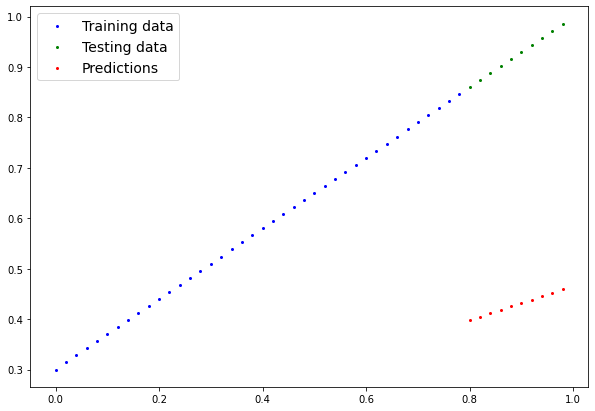

In [12]:
plot_predictions(predictions=y_preds)

In [13]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

哇，这些预测看起来确实不太好……

但这很正常，因为当前模型还只是用随机参数在做预测。

它甚至还没真正“看懂”蓝点去预测绿点。

是时候改变这一点了。

## 3. 训练模型

当前模型使用随机参数进行计算，本质上是在随机猜测。

要修复这个问题，我们需要更新模型内部参数（我有时也把 *parameters* 称为 patterns），也就是通过 `nn.Parameter()` 和 `torch.randn()` 随机初始化的 `weights` 与 `bias`，让它们更好地表示数据规律。

我们当然可以手工写死这些值（因为我们知道构造数据时用了 `weight=0.7` 和 `bias=0.3`），但那就没有意思了。

大多数时候，你并不知道模型的理想参数是什么。

更有意思也更实用的是：写代码让模型自己尝试找到它们。



### 在 PyTorch 中创建损失函数与优化器

为了让模型自行更新参数，我们还需要在配方里加入两样东西：

一个 **损失函数** 和一个 **优化器**。

它们各自的作用：

| 组件 | 它做什么？ | 在 PyTorch 中哪里？ | 常见取值 |
| ----- | ----- | ----- | ----- |
| **损失函数** | 衡量模型预测（如 `y_preds`）与真实标签（如 `y_test`）有多“错”。越小越好。 | PyTorch 在 [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions) 中内置了很多损失函数。 | 回归常用平均绝对误差 MAE（[`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)）；二分类常用二元交叉熵（[`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)）。  |
| **优化器** | 告诉模型如何更新内部参数以更好降低损失。 | 在 [`torch.optim`](https://pytorch.org/docs/stable/optim.html) 中有多种实现。 | 随机梯度下降（[`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)）、Adam（[`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)）。 | 

现在创建一个损失函数和优化器来改进模型。

具体使用哪种损失函数和优化器取决于你的任务。

不过有一些常见且效果稳定的选择，例如 SGD 或 Adam；对于回归问题（预测数值）常用 MAE，对于分类问题（二选一等）常用二元交叉熵。

在我们这个任务中是预测数值，因此使用 MAE（PyTorch 中对应 `torch.nn.L1Loss()`）作为损失函数。

![what MAE loss looks like for our plot data](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png)
*平均绝对误差（MAE，在 PyTorch 中为 `torch.nn.L1Loss`）会先计算预测与标签逐点绝对差，再对全部样本取平均。*

优化器我们使用 SGD，即 `torch.optim.SGD(params, lr)`，其中：

* `params` 是要优化的目标模型参数（例如前面随机初始化的 `weights` 和 `bias`）。
* `lr` 是 **学习率**，控制每一步参数更新幅度。较大学习率更新更猛（可能过大而不稳定），较小学习率更新更缓（可能收敛太慢）。学习率属于 **超参数**（由工程师设定）。常见起始值有 `0.01`、`0.001`、`0.0001`，也可随训练动态调整（称为 [learning rate scheduling](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)）。

信息很多，先看代码。

In [ ]:
# 创建损失函数
loss_fn = nn.L1Loss() # MAE loss 等价于 L1Loss

# 创建优化器
optimizer = torch.optim.SGD(params=model_0.parameters(), # 要优化的目标模型参数
                            lr=0.01) # 学习率（每步更新幅度：大=更快但可能不稳，小=更稳但可能较慢）

### 在 PyTorch 中创建优化循环

太好了！现在我们有了损失函数和优化器，接下来就该构建 **训练循环**（和 **测试循环**）。

训练循环让模型遍历训练数据，学习 `features` 与 `labels` 的关系。

测试循环让模型遍历测试数据，评估它在训练数据上学到的模式是否有效（训练阶段模型不会看到测试数据）。

之所以叫“循环”，是因为我们希望模型把数据集中的每个样本都看一遍（循环遍历）。

我们会写一个 Python `for` 循环，并借用 [非官方 PyTorch 优化循环口诀](https://twitter.com/mrdbourke/status/1450977868406673410?s=20) 的节奏（也有[视频版](https://youtu.be/Nutpusq_AFw)）。

![the unofficial pytorch optimization loop song](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-optimization-loop-song.png)
*非官方 PyTorch 优化循环口诀：一种有趣的方式来记住训练（与测试）循环步骤。*

代码会稍多，但完全在可控范围内。




### PyTorch 训练循环
训练循环可以按以下步骤搭建：

| 序号 | 步骤名 | 它做什么？ | 代码示例 |
| ----- | ----- | ----- | ----- |
| 1 | 前向传播 | 模型完整遍历一次训练数据，并执行 `forward()` 计算。 | `model(x_train)` |
| 2 | 计算损失 | 将模型输出（预测）与真实值对比，衡量错得有多大。 | `loss = loss_fn(y_pred, y_train)` | 
| 3 | 梯度清零 | 将优化器中的梯度置零（梯度默认会累积），以便当前步重新计算。 | `optimizer.zero_grad()` |
| 4 | 反向传播 | 计算损失相对于每个待更新参数（`requires_grad=True`）的梯度，这一步叫 **backpropagation**。  | `loss.backward()` |
| 5 | 优化器更新（**梯度下降**） | 根据损失梯度更新 `requires_grad=True` 的参数，使模型变好。 | `optimizer.step()` |

![pytorch training loop annotated](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

> **注意：** 上面只是步骤组织的一种常见写法。随着经验增长，你会发现 PyTorch 训练循环写法很灵活。
>
> 至于顺序，以上是很好的默认顺序，但你也可能看到轻微差异。几个经验规则：
> * 先计算损失（`loss = ...`），再对其反向传播（`loss.backward()`）。
> * 先清零梯度（`optimizer.zero_grad()`），再计算梯度（`loss.backward()`）。
> * 先反向传播（`loss.backward()`），再执行优化器更新（`optimizer.step()`）。

若想深入理解反向传播和梯度下降背后的机制，可看文末拓展学习。



### PyTorch 测试循环

对于测试循环（即评估模型），典型步骤包括：

| 序号 | 步骤名 | 它做什么？ | 代码示例 |
| ----- | ----- | ----- | ----- |
| 1 | 前向传播 | 模型完整遍历一次测试数据并执行 `forward()` 计算。 | `model(x_test)` |
| 2 | 计算损失 | 将模型输出（预测）与真实值对比，衡量错得有多大。 | `loss = loss_fn(y_pred, y_test)` | 
| 3 | 计算评估指标（可选） | 除了损失，还可计算其他评估指标（如测试集准确率）。 | 自定义函数 |

注意测试循环不包含反向传播（`loss.backward()`）和优化器更新（`optimizer.step()`），因为测试时模型参数不再变化，参数更新在训练阶段已经完成。测试阶段我们只关心前向输出。

![pytorch annotated testing loop](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-testing-loop-annotated.png)

现在把上面步骤整合起来，让模型训练 100 个 **epochs**（完整遍历数据 100 次），并每 10 个 epoch 评估一次。


In [ ]:
torch.manual_seed(42)

# 设置 epoch 数（模型遍历训练数据的轮数）
epochs = 100

# 创建空列表用于跟踪损失值
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### 训练阶段

    # 将模型设为训练模式（模型默认状态）
    model_0.train()

    # 1. 在训练数据上做前向传播（调用 forward()）
    y_pred = model_0(X_train)
    # 打印 y_pred

    # 2. 计算损失（模型预测与真实值的差距）
    loss = loss_fn(y_pred, y_train)

    # 3. 优化器梯度清零
    optimizer.zero_grad()

    # 4. 反向传播
    loss.backward()

    # 5. 优化器更新参数
    optimizer.step()

    ### 测试阶段

    # 将模型设为评估模式
    model_0.eval()

    with torch.inference_mode():
      # 1. 在测试数据上做前向传播
      test_pred = model_0(X_test)

      # 2. 计算测试损失
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # 预测是 torch.float，因此对比张量类型需一致

      # 打印训练过程
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


看看这个结果！每个 epoch 损失都在下降，我们把它画出来看看。

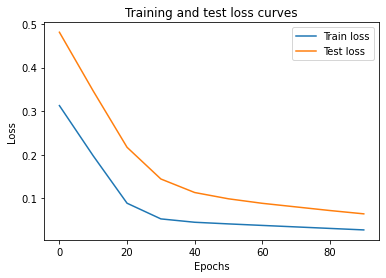

In [ ]:
# 绘制损失曲线
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

很好！**损失曲线** 展示了损失值随时间下降。记住，损失衡量的是模型有多“错”，因此越低越好。

但损失为什么会下降？

因为在损失函数与优化器的作用下，模型内部参数（`weights` 和 `bias`）被持续更新，更接近数据中的真实模式。

我们检查模型的 [`.state_dict()`](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)，看看它学习到的参数与我们最初设定的权重和偏置有多接近。


In [ ]:
# 查看模型学到的参数
print("模型学习到的权重和偏置如下:")
print(model_0.state_dict())
print("\n而我们原始设定的权重和偏置是:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


很酷，对吧？

模型已经非常接近我们最初设定的 `weight` 与 `bias`（如果训练更久，通常还会更接近）。

> **练习：** 把上面的 `epochs` 改为 200，观察损失曲线，以及模型权重和偏置会发生什么变化。

它很可能不会 *完全* 猜中（尤其在更复杂的数据集上），但这没关系，接近真实值往往已经足够解决很多实际问题。

这正是机器学习和深度学习的核心思想：**数据背后存在一组理想参数**，与其手工推导，**不如训练模型自动逼近这些参数**。

## 4. 使用训练好的 PyTorch 模型进行预测（推理）

模型训练完成后，你通常会希望用它来做预测。

我们在上面的训练/测试代码里已经看到了一点，脱离循环做推理时步骤类似。

用 PyTorch 模型做预测（inference）时记住三点：

1. 将模型设为评估模式（`model.eval()`）。
2. 在推理上下文中预测（`with torch.inference_mode(): ...`）。
3. 模型与数据必须在同一设备上（例如都在 GPU，或都在 CPU）。

前两项会关闭训练阶段才需要、推理不需要的幕后计算和设置，从而让推理更快；第三项可避免跨设备报错。

In [ ]:
# 1. 将模型设为评估模式
model_0.eval()

# 2. 使用推理模式上下文管理器
with torch.inference_mode():
  # 3. 确保模型和数据在同一设备上
  # 当前我们还没写设备无关代码，所以模型与数据默认都在 CPU
  # model_0.to(device)  # 若使用设备无关代码可启用
  # X_test = X_test.to(device)  # 若使用设备无关代码可启用
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

不错！我们已经用训练好的模型做出了预测，现在看看效果如何？

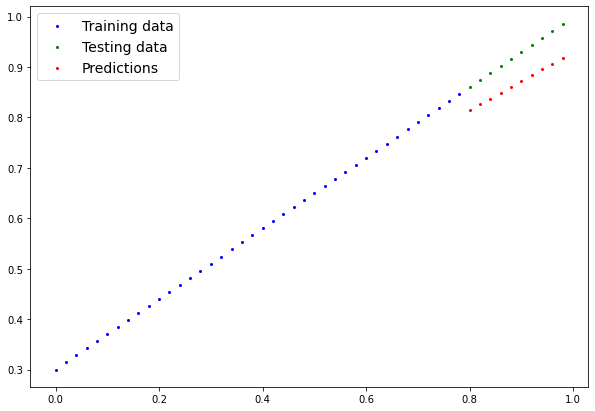

In [19]:
plot_predictions(predictions=y_preds)

太棒了！这些红点比之前贴近得多。

接下来进入 PyTorch 中的模型保存与加载。

## 5. 保存与加载 PyTorch 模型

训练完 PyTorch 模型后，你大概率会想保存并导出它。

例如你可能在 Google Colab 或本地 GPU 机器上训练模型，然后希望将模型导出到某个应用供他人使用。

或者你想保存当前训练进度，之后再加载继续。

在 PyTorch 中，保存和加载模型有三个核心方法需要了解（以下内容参考 [PyTorch saving and loading models guide](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference)）：

| PyTorch 方法 | 它做什么？ | 
| ----- | ----- |
| [`torch.save`](https://pytorch.org/docs/stable/torch.html?highlight=save#torch.save) | 使用 Python 的 [`pickle`](https://docs.python.org/3/library/pickle.html) 工具将对象序列化并保存到磁盘。模型、张量和字典等 Python 对象都可保存。  | 
| [`torch.load`](https://pytorch.org/docs/stable/torch.html?highlight=torch%20load#torch.load) | 使用 `pickle` 的反序列化能力将对象（如模型、张量、字典）加载到内存中，也可指定加载设备（CPU、GPU 等）。 |
| [`torch.nn.Module.load_state_dict`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict)| 用保存下来的 `state_dict()` 对象加载模型参数字典（`model.state_dict()`）。 | 



### 保存 PyTorch 模型的 `state_dict()`

对于推理场景（做预测），[推荐方式](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference)是保存并加载模型的 `state_dict()`。

按下面几步做：

1. 用 Python 的 `pathlib` 创建一个 `models` 目录用于保存模型。
2. 创建模型保存路径。
3. 调用 `torch.save(obj, f)`，其中 `obj` 是目标模型的 `state_dict()`，`f` 是保存文件名。

> **注意：** PyTorch 中保存的模型或对象通常以 `.pt` 或 `.pth` 结尾，例如 `saved_model_01.pth`。


In [ ]:
from pathlib import Path

# 1. 创建 models 目录
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. 创建模型保存路径
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 保存模型 state_dict
print(f"保存模型到: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # 仅保存 state_dict()，即模型学到的参数
           f=MODEL_SAVE_PATH) 

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
# 检查保存文件路径
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-rw-r-- 1 daniel daniel 1063 Nov 10 16:07 models/01_pytorch_workflow_model_0.pth


### 加载已保存的 PyTorch 模型 `state_dict()`

既然我们已经把 `state_dict()` 保存到 `models/01_pytorch_workflow_model_0.pth`，现在就可以使用 `torch.nn.Module.load_state_dict(torch.load(f))` 进行加载，其中 `f` 是保存路径。

为什么是 `torch.nn.Module.load_state_dict()` 里再调用 `torch.load()`？

因为我们保存的是模型的 `state_dict()`（参数字典），而不是 *完整模型*。因此要先 `torch.load()` 读取 `state_dict()`，再把它传给新建的模型实例（`nn.Module` 子类）。

那为什么不直接保存整个模型？

相比只保存 `state_dict()`，[保存整个模型](https://pytorch.org/tutorials/beginner/saving_loading_models.html#save-load-entire-model)看上去更直观。但 PyTorch 文档里提到（下面为原意）：

> 这种方式（保存完整模型）的缺点是：序列化数据会绑定到保存时的具体类定义与目录结构……
>
> 因此，在其他项目中使用或代码重构后，很容易出现兼容性问题。

所以我们采用更灵活的方式：只保存和加载 `state_dict()`（本质上就是模型参数字典）。

下面通过创建一个新的 `LinearRegressionModel()` 实例来验证，它作为 `torch.nn.Module` 子类，天然支持 `load_state_dict()`。

In [ ]:
# 实例化一个新模型（初始是随机权重）
loaded_model_0 = LinearRegressionModel()

# 加载已保存模型的 state_dict（会把新模型更新为训练后权重）
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

很好！看起来已经匹配上了。

现在测试一下加载后的模型：我们在测试集上做推理，看看结果是否与保存前一致。

还记得 PyTorch 推理规则吗？

如果不记得，这里快速回顾：

<details>
    <summary>PyTorch 推理规则</summary>
    <ol>
      <li> 将模型设为评估模式（<code>model.eval()</code>）。 </li>
      <li> 在推理模式上下文中执行预测（<code>with torch.inference_mode(): ...</code>）。 </li>
      <li> 所有预测对象应位于同一设备（如模型与数据都在 GPU，或都在 CPU）。</li>
    </ol> 
</details>



In [ ]:
# 1. 将加载后的模型设为评估模式
loaded_model_0.eval()

# 2. 使用推理模式上下文管理器做预测
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # 在测试数据上执行一次前向传播

现在我们已经用加载后的模型做了预测，来检查它是否与保存前预测一致。

In [ ]:
# 对比保存前模型与加载后模型预测（应一致）
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

很好！

加载后模型的预测与保存前一致，说明模型保存/加载流程符合预期。

 > **注意：** PyTorch 还有更多模型保存加载方式，这里先不展开。可参考 [PyTorch 保存与加载指南](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-and-loading-models)。

## 6. 全部串起来

到目前为止我们已经覆盖了不少内容。

当你多练几次后，这些步骤会像走路一样自然。

说到练习，现在把我们前面做过的全部流程整合起来。

这次我们让代码具备设备无关性（有 GPU 就用 GPU，没有就回退 CPU）。

这一节注释会比上面少一些，因为核心内容前面已经讲过。

先从导入需要的标准库开始。

> **注意：** 如果你在 Google Colab 使用 GPU，请到 Runtime -> Change runtime type -> Hardware acceleration -> GPU。切换后会重置 Colab 运行时，已保存变量会丢失。

In [ ]:
# 导入 PyTorch 和 matplotlib
import torch
from torch import nn # nn 包含 PyTorch 中神经网络的基础模块
import matplotlib.pyplot as plt

# 检查 PyTorch 版本
torch.__version__

'1.12.1+cu113'

先把代码设为设备无关：若可用则 `device="cuda"`，否则回退到 `device="cpu"`。



In [ ]:
# 设备无关设置
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

Using device: cuda


如果你有 GPU，上面通常会输出：

```
Using device: cuda
```

否则后续计算会使用 CPU。对于当前小数据集这没问题，但在大数据集上会更慢。

### 6.1 数据

像前面一样先创建数据。

先手动设定 `weight` 和 `bias`。

再创建 0 到 1 之间的一组数作为 `X`。

最后用线性回归公式（`y = weight * X + bias`）生成 `y`。

In [ ]:
# 创建权重和偏置
weight = 0.7
bias = 0.3

# 创建取值范围
start = 0
end = 1
step = 0.02

# 创建 X 和 y（特征与标签）
X = torch.arange(start, end, step).unsqueeze(dim=1) # 不做 unsqueeze 后续线性层会因 shape 报错
y = weight * X + bias 
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

很好！

现在数据准备好了，接下来切分训练集和测试集。

我们使用 80/20 切分：80% 训练，20% 测试。

In [ ]:
# 切分数据
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

很好，我们把它们可视化确认一下。

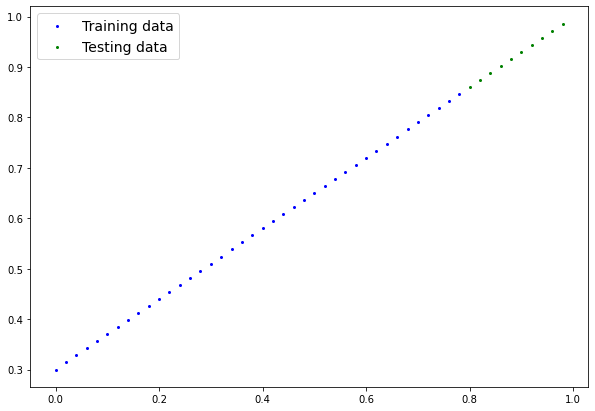

In [ ]:
# 注意：如果你重置过运行时，这个函数可能不可用，
# 需要重新运行上面定义函数的单元格。
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 构建 PyTorch 线性模型

数据准备好后，开始构建模型。

我们会保持和前面类似的模型风格，但这次不再手动用 `nn.Parameter()` 定义权重和偏置，而是直接使用 [`nn.Linear(in_features, out_features)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)。

其中 `in_features` 是输入维度数，`out_features` 是输出维度数。

在我们的例子里两者都为 `1`，因为每个标签 `y` 只对应 1 个输入特征 `X`。

![comparison of nn.Parameter Linear Regression model and nn.Linear Linear Regression model](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-regression-model-with-nn-Parameter-and-nn-Linear-compared.png)
*使用 `nn.Parameter` 与 `nn.Linear` 构建线性回归模型的对比。`torch.nn` 里还有很多预构建计算与常用神经网络层可直接使用。*


In [ ]:
# 继承 nn.Module 构建模型
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # 使用 nn.Linear() 创建模型参数
        self.linear_layer = nn.Linear(in_features=1, 
                                      out_features=1)
    
    # 定义前向计算（输入 x 经过 nn.Linear()）
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# 创建模型时设置随机种子（演示用途，可尝试注释掉观察差异）
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

观察 `model_1.state_dict()` 输出，`nn.Linear()` 已经自动为我们创建了随机 `weight` 和 `bias` 参数。

接下来把模型放到 GPU（如果可用）。

我们可以用 `.to(device)` 修改 PyTorch 对象所在设备。

先检查模型当前设备。

In [ ]:
# 检查模型设备
next(model_1.parameters()).device

device(type='cpu')

很好，模型默认在 CPU 上。

现在把它切到 GPU（如果可用）。

In [ ]:
# 若可用则把模型放到 GPU，否则默认 CPU
model_1.to(device) # device 在上面已设置：有 cuda 用 cuda，否则 cpu
next(model_1.parameters()).device

device(type='cuda', index=0)

很好！由于我们使用了设备无关代码，这个单元格无论有无 GPU 都能运行。

如果你有可用 CUDA GPU，输出通常类似：

```
device(type='cuda', index=0)
```

### 6.3 训练

现在开始构建训练与测试循环。

首先需要损失函数和优化器。

我们沿用前面同样的配置：`nn.L1Loss()` 和 `torch.optim.SGD()`。

需要把新模型的参数（`model.parameters()`）传给优化器，训练时它才能更新参数。

学习率 `0.01` 在前面效果不错，这里继续使用。




In [ ]:
# 创建损失函数
loss_fn = nn.L1Loss()

# 创建优化器
optimizer = torch.optim.SGD(params=model_1.parameters(), # 优化新模型参数
                            lr=0.01)

很好，损失函数和优化器都准备好了。现在用训练/测试循环来训练并评估模型。

和前一版训练循环相比，本次唯一关键差异是：把数据也放到目标 `device` 上。

模型已经通过 `model_1.to(device)` 放到了目标设备上。

数据也同样处理。

这样当模型在 GPU 上时，数据也在 GPU 上（反之亦然）。

这次再提高一点强度，设置 `epochs=1000`。

如果你需要回顾 PyTorch 训练循环步骤，见下方。

<details>
    <summary>PyTorch 训练循环步骤</summary>
    <ol>
        <li><b>前向传播</b> - 模型完整遍历一次训练数据，并执行
            <code>forward()</code>
            计算（<code>model(x_train)</code>）。
        </li>
        <li><b>计算损失</b> - 将模型输出（预测）与真实值比较，评估误差大小
            （例如：<code>loss = loss_fn(y_pred, y_train)</code>）。</li>
        <li><b>梯度清零</b> - 将优化器中的梯度归零（梯度默认会累积）
            以便当前训练步重新计算（<code>optimizer.zero_grad()</code>）。</li>
        <li><b>反向传播</b> - 计算损失相对于每个模型参数的梯度（仅对
            <code>requires_grad=True</code> 的参数），也就是 <b>backpropagation</b>
            （例如：<code>loss.backward()</code>）。</li>
        <li><b>优化器更新（梯度下降）</b> - 按损失梯度更新
            <code>requires_grad=True</code> 的参数
            以改进模型（<code>optimizer.step()</code>）。</li>
    </ol>
</details>

In [ ]:
torch.manual_seed(42)

# 设置训练轮数
epochs = 1000

# 将数据放到目标设备上
# 不这样做会报错（模型与数据不在同一设备）
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### 训练阶段
    model_1.train() # 模型构建后默认是 train 模式

    # 1. 前向传播
    y_pred = model_1(X_train)

    # 2. 计算损失
    loss = loss_fn(y_pred, y_train)

    # 3. 优化器梯度清零
    optimizer.zero_grad()

    # 4. 反向传播
    loss.backward()

    # 5. 优化器更新
    optimizer.step()

    ### 测试阶段
    model_1.eval() # 测试（推理）时设为评估模式
    # 1. 前向传播
    with torch.inference_mode():
        test_pred = model_1(X_test)
    
        # 2. 计算损失
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 100 | Train loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 200 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


> **注意：** 由于机器学习本身含随机性，即便使用同一个随机种子，模型在 CPU 与 GPU 上训练也可能得到略有差异的结果（损失和预测值）。如果差异很大要排查问题；若差异很小（理想情况），通常可以接受。

很好！这个损失已经很低了。

现在检查模型学到的参数，并与我们手动设定的原始参数对比。

In [ ]:
# 查看模型学到的参数
from pprint import pprint # pprint = pretty print，详见: https://docs.python.org/3/library/pprint.html 
print("模型学习到的权重和偏置如下:")
pprint(model_1.state_dict())
print("\n而我们原始设定的权重和偏置是:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


这已经非常接近“完美模型”了。

不过记住，真实场景里你通常不会提前知道最优参数。

如果你一开始就知道模型必须学到的参数，那机器学习也就失去意义了。

而且在很多真实任务中，参数量往往是数千万级别。

比起手工推，我更愿意写代码交给计算机去搞定。

### 6.4 做预测

现在我们已经有了训练好的模型，切换到评估模式并进行预测。

In [ ]:
# 将模型切换到评估模式
model_1.eval()

# 在测试数据上做预测
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

如果你用 GPU 上的数据做预测，可能会看到输出末尾带 `device='cuda:0'`。这表示数据在 CUDA 设备 0（系统可用的第一张 GPU，编号从 0 开始）。如果未来使用多 GPU，这个编号可能更大。

现在把模型预测结果画出来。

> **注意：** 很多数据科学库（如 pandas、matplotlib、NumPy）不能直接处理 GPU 上的数据。因此你在把张量传给这些库时可能报错。解决方法是先对目标张量调用 [`.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html)，将其复制到 CPU。

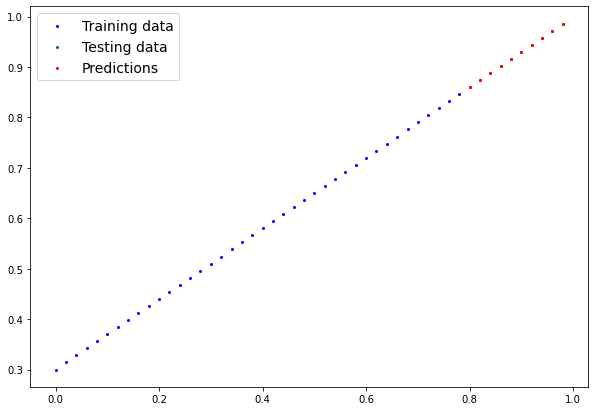

In [ ]:
# plot_predictions(predictions=y_preds) # -> 不可用... 数据不在 CPU

# 将数据放回 CPU 后再绘图
plot_predictions(predictions=y_preds.cpu())

哇！看这些红点，几乎与绿点重合。看来增加 epochs 确实有帮助。


### 6.5 保存与加载模型

我们对模型预测效果满意了，接下来把它保存到文件，便于后续复用。


In [ ]:
from pathlib import Path

# 1. 创建 models 目录
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. 创建模型保存路径
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 保存模型 state_dict
print(f"保存模型到: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # 仅保存 state_dict()，即模型学到的参数
           f=MODEL_SAVE_PATH) 

Saving model to: models/01_pytorch_workflow_model_1.pth


为了确认一切正常，我们再把它加载回来。

我们会：
* 新建一个 `LinearRegressionModelV2()` 实例
* 用 `torch.nn.Module.load_state_dict()` 加载模型参数字典
* 把新模型实例放到目标设备上（保证代码设备无关）

In [ ]:
# 新建一个 LinearRegressionModelV2 实例
loaded_model_1 = LinearRegressionModelV2()

# 加载模型 state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# 把模型放到目标设备（若数据在 GPU，模型也必须在 GPU 才能预测）
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


现在我们可以评估加载后的模型，检查其预测是否与保存前一致。

In [ ]:
# 评估加载后的模型
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

全部对上了！很好！

我们已经走了很长一段路。你现在已经在 PyTorch 里构建并训练了前两个神经网络模型。

接下来就是练习巩固。

## 练习

所有练习都基于本 notebook 中的代码设计。

每个主要章节对应一个练习。

你应该可以通过回看对应章节完成它们。

> **注意：** 所有练习代码都应保持设备无关（即可在 CPU 上运行，也可在 GPU 可用时运行）。

1. 使用线性回归公式（`weight * X + bias`）创建一条直线数据集。
  * 设定 `weight=0.3`、`bias=0.9`，总数据点至少 100 个。
  * 将数据按 80% 训练、20% 测试切分。
  * 可视化训练集与测试集。
2. 通过继承 `nn.Module` 构建一个 PyTorch 模型。
  * 模型内部应有两个随机初始化且 `requires_grad=True` 的 `nn.Parameter()`：一个 `weights`，一个 `bias`。
  * 实现 `forward()`，计算你在第 1 题中使用的线性回归函数。
  * 构建模型实例并检查其 `state_dict()`。
  * **注意：** 你也可以用 `nn.Linear()` 替代 `nn.Parameter()`。
3. 使用 `nn.L1Loss()` 与 `torch.optim.SGD(params, lr)` 分别创建损失函数和优化器。
  * 优化器学习率设为 0.01，优化参数应来自你在第 2 题创建的模型。
  * 编写训练循环并训练 300 个 epoch。
  * 每 20 个 epoch 在测试集上评估一次模型。
4. 用训练好的模型在测试集上做预测。
  * 将预测与原始训练/测试数据可视化对比（**注意：** 若使用 matplotlib 等非 CUDA 库绘图，需确保预测张量不在 GPU 上）。
5. 将训练好模型的 `state_dict()` 保存到文件。
  * 新建一个你在第 2 题定义的模型实例，并加载刚保存的 `state_dict()`。
  * 用加载后的模型在测试集上预测，并确认结果与第 4 题原模型预测一致。

> **资源：** 可参考课程 GitHub 上的 [练习模板](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/exercises) 与 [参考解答](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions)。

## 拓展学习
* 听一遍 [The Unofficial PyTorch Optimization Loop Song](https://youtu.be/Nutpusq_AFw)（帮助记忆 PyTorch 训练/测试循环步骤）。
* 阅读 Jeremy Howard 的 [What is `torch.nn`, really?](https://pytorch.org/tutorials/beginner/nn_tutorial.html)，更深入理解 PyTorch 核心模块之一。
* 花 10 分钟浏览 [PyTorch 文档速查表](https://pytorch.org/tutorials/beginner/ptcheat.html)，熟悉常见模块。
* 花 10 分钟阅读 [PyTorch 保存与加载文档](https://pytorch.org/tutorials/beginner/saving_loading_models.html)，熟悉不同保存加载方式。
* 花 1-2 小时阅读/观看下列内容，理解梯度下降与反向传播这两个关键算法：
 * [梯度下降 Wikipedia](https://en.wikipedia.org/wiki/Gradient_descent)
 * [梯度下降算法深度解析](https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21)（Robert Kwiatkowski）
 * [梯度下降：神经网络如何学习](https://youtu.be/IHZwWFHWa-w)（3Blue1Brown）
 * [反向传播到底在做什么？](https://youtu.be/Ilg3gGewQ5U)（3Blue1Brown）
 * [反向传播 Wikipedia](https://en.wikipedia.org/wiki/Backpropagation)
